In [3]:
# Importing  libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report



In [13]:

# path comes from kagglehub.dataset_download(...)
import os
dataset_path = "animals_dataset"

# sanity check
print("Dataset path:", dataset_path)
print("Path exists:", os.path.exists(dataset_path))

# list classes
classes = sorted(os.listdir(dataset_path))
num_classes = len(classes)

print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")


Dataset path: animals_dataset
Path exists: True
Number of classes: 90
Classes: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']


In [14]:
def visualize_sample_images(dataset_path, classes, num_images = 10):
    plt.figure(figsize=(15, 10))

    for i, class_name in enumerate(classes[:num_images]):
        class_path = os.path.join(dataset_path, class_name)
        img_list = os.listdir(class_path)

        if not img_list:  # Skip empty folders
            continue

        img_path = os.path.join(class_path, img_list[0])
        img = plt.imread(img_path)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f'{class_name} \n shape: {img.shape}')
        plt.axis('off')

    plt.show()



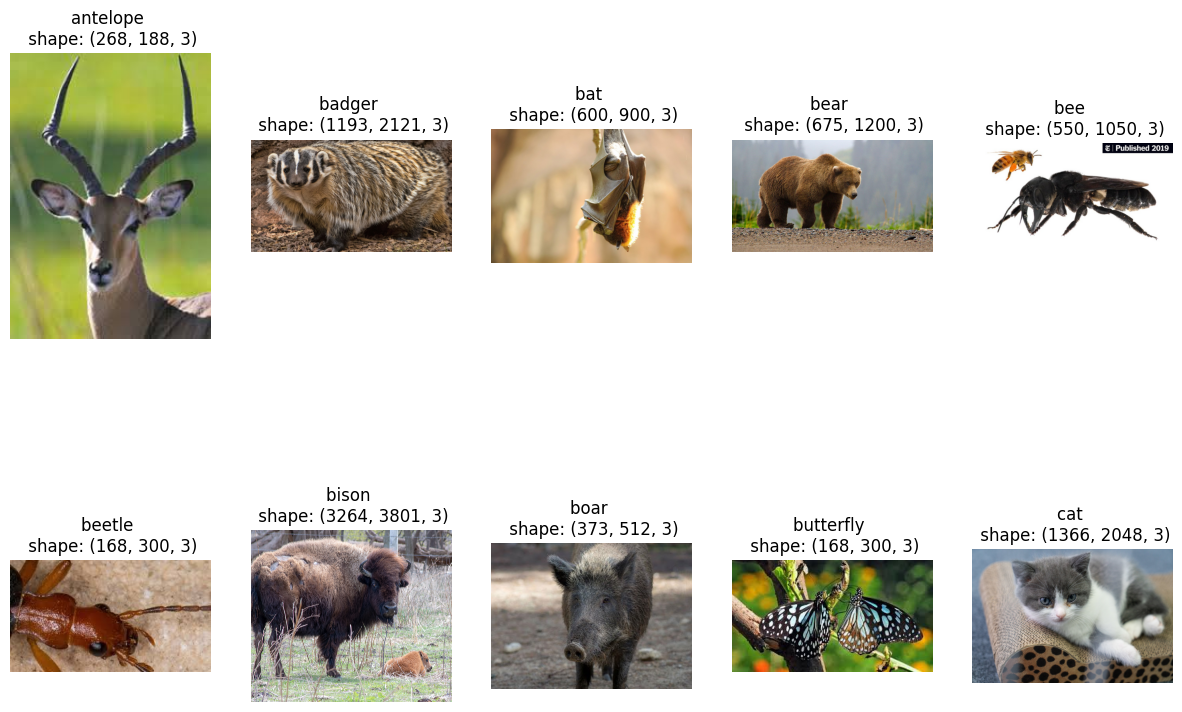

In [15]:
# Call the function to display images
visualize_sample_images(dataset_path, classes)


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Define image size and batch_size
img_size = (224, 224)
batch_size = 64

# Slightly improved Data Augmentation and preprocessing
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Replaces rescale=1./255
    validation_split=0.1,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Create training and validation generators
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 4860 images belonging to 90 classes.
Found 540 images belonging to 90 classes.


In [17]:

# Map the classes - class_indices
class_indices = train_generator.class_indices
print(class_indices)
# Extract class names
class_names = list(class_indices.keys())
print("Class Names:", class_names)



{'antelope': 0, 'badger': 1, 'bat': 2, 'bear': 3, 'bee': 4, 'beetle': 5, 'bison': 6, 'boar': 7, 'butterfly': 8, 'cat': 9, 'caterpillar': 10, 'chimpanzee': 11, 'cockroach': 12, 'cow': 13, 'coyote': 14, 'crab': 15, 'crow': 16, 'deer': 17, 'dog': 18, 'dolphin': 19, 'donkey': 20, 'dragonfly': 21, 'duck': 22, 'eagle': 23, 'elephant': 24, 'flamingo': 25, 'fly': 26, 'fox': 27, 'goat': 28, 'goldfish': 29, 'goose': 30, 'gorilla': 31, 'grasshopper': 32, 'hamster': 33, 'hare': 34, 'hedgehog': 35, 'hippopotamus': 36, 'hornbill': 37, 'horse': 38, 'hummingbird': 39, 'hyena': 40, 'jellyfish': 41, 'kangaroo': 42, 'koala': 43, 'ladybugs': 44, 'leopard': 45, 'lion': 46, 'lizard': 47, 'lobster': 48, 'mosquito': 49, 'moth': 50, 'mouse': 51, 'octopus': 52, 'okapi': 53, 'orangutan': 54, 'otter': 55, 'owl': 56, 'ox': 57, 'oyster': 58, 'panda': 59, 'parrot': 60, 'pelecaniformes': 61, 'penguin': 62, 'pig': 63, 'pigeon': 64, 'porcupine': 65, 'possum': 66, 'raccoon': 67, 'rat': 68, 'reindeer': 69, 'rhinoceros': 

In [16]:
# Load MobileNetV2 as the base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model weights, training
base_model.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x) # output layer

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
# Model summary
model.summary()

9406464/9406464 [==============================] - 1s 0us/step


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

In [17]:


# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs = 20
)



Epoch 1/20
75/75 [==============================] - 30s 383ms/step - loss: 4.1292 - accuracy: 0.1153 - val_loss: 3.2272 - val_accuracy: 0.5586
Epoch 2/20
75/75 [==============================] - 29s 387ms/step - loss: 2.7145 - accuracy: 0.4744 - val_loss: 1.8997 - val_accuracy: 0.7031
Epoch 3/20
75/75 [==============================] - 30s 396ms/step - loss: 1.6637 - accuracy: 0.6555 - val_loss: 1.1831 - val_accuracy: 0.7773
Epoch 4/20
75/75 [==============================] - 31s 408ms/step - loss: 1.1850 - accuracy: 0.7360 - val_loss: 0.9285 - val_accuracy: 0.7949
Epoch 5/20
75/75 [==============================] - 31s 414ms/step - loss: 0.9184 - accuracy: 0.7781 - val_loss: 0.7924 - val_accuracy: 0.8164
Epoch 6/20
75/75 [==============================] - 32s 427ms/step - loss: 0.8009 - accuracy: 0.8081 - val_loss: 0.7251 - val_accuracy: 0.8203
Epoch 7/20
75/75 [==============================] - 35s 460ms/step - loss: 0.6849 - accuracy: 0.8286 - val_loss: 0.6402 - val_accuracy: 0.8359

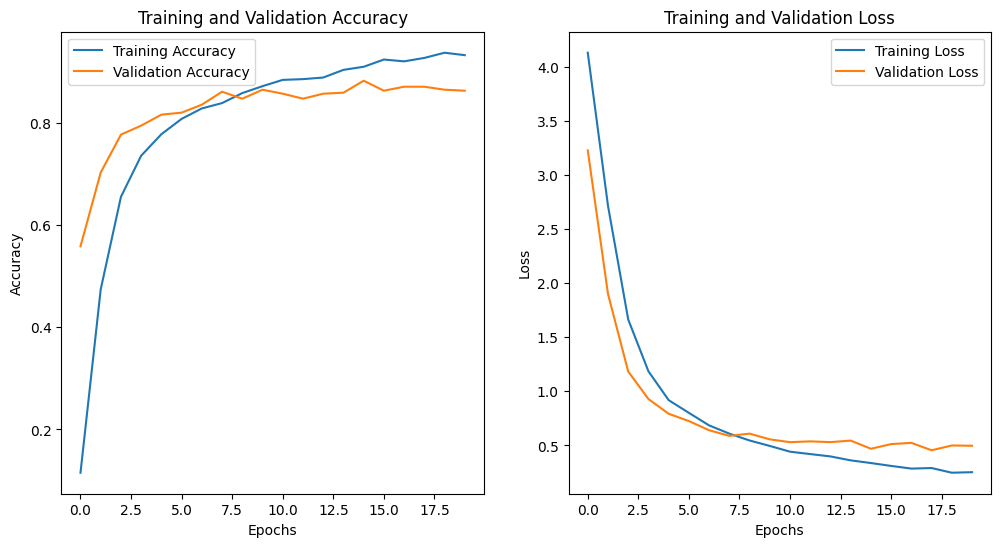

In [18]:
# Evaluate the model - plotting the training and validation acc/loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.show()

In [19]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

9/9 [==============================] - 3s 311ms/step - loss: 0.4756 - accuracy: 0.8759
Validation Loss: 0.4756081998348236
Validation Accuracy: 0.8759258985519409


In [30]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


def predict_animal(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # MobileNetV2 preprocessing
    img_array = preprocess_input(img_array)

    # Prediction
    prediction = model(img_array, training=False)
    class_index = np.argmax(prediction)
    predicted_class = class_names[class_index]
    confidence = np.max(prediction) * 100

    # Display
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()



In [25]:
parrot_dir = os.path.join(dataset_path, "parrot")
images = os.listdir(parrot_dir)

print(images)  # show first 5 images


['036b760476.jpg', '0b2a1e349a.jpg', '060cca8826.jpg', '5d18e7e995.jpg', '3a0c5d4582.jpg', '4c26cd72e2.jpg', '27a9ce4e1a.jpg', '6a184a05f3.jpg', '0100ec7408.jpg', '89d679b9e5.jpg', '96c5e35a54.jpg', '50e40b5356.jpg', '61def3553e.jpg', '4af25ae32d.jpg', '62fc818264.jpg', '8a8a69d934.jpg', '47ef39ceb6.jpg', '7a7fdb0450.jpg', '6be2eb3fb3.jpg', '56b19e9dbc.jpg', '5b1030ddd5.jpg', '4aba5914cd.jpg', '64bd254fef.jpg', '3ac69be3f6.jpg', '0d778c6833.jpg', '080a286cf3.jpg', '66e79b1a2f.jpg', '84b6622dbc.jpg', '47d00fc79f.jpg', '0f072e6ce1.jpg', '3f5e9e225b.jpg', '7b8d54f49e.jpg', '1bcd666a4e.jpg', '7dab3a1142.jpg', '8f5a2730b3.jpg', '91f0604cc7.jpg', '46de4406fb.jpg', '1f4f736dbf.jpg', '1cabf8a760.jpg', '9d0d266d23.jpg', '46ed4828b1.jpg', '0b29c10342.jpg', '25e773e479.jpg', '9c2dd51734.jpg', '4faf55514e.jpg', '7d5cb5f5fa.jpg', '64c08f053c.jpg', '8cdc657d99.jpg', '6a0ab0de34.jpg', '4ead913624.jpg', '1b9f359f9c.jpg', '29c26708a0.jpg', '34f9668c8e.jpg', '3de507dbb6.jpg', '2f207b75e3.jpg', '60e0c50a

In [27]:
elephant_dir = os.path.join(dataset_path, "elephant")
images = os.listdir(parrot_dir)
print(images)  # show first 5 images

['036b760476.jpg', '0b2a1e349a.jpg', '060cca8826.jpg', '5d18e7e995.jpg', '3a0c5d4582.jpg', '4c26cd72e2.jpg', '27a9ce4e1a.jpg', '6a184a05f3.jpg', '0100ec7408.jpg', '89d679b9e5.jpg', '96c5e35a54.jpg', '50e40b5356.jpg', '61def3553e.jpg', '4af25ae32d.jpg', '62fc818264.jpg', '8a8a69d934.jpg', '47ef39ceb6.jpg', '7a7fdb0450.jpg', '6be2eb3fb3.jpg', '56b19e9dbc.jpg', '5b1030ddd5.jpg', '4aba5914cd.jpg', '64bd254fef.jpg', '3ac69be3f6.jpg', '0d778c6833.jpg', '080a286cf3.jpg', '66e79b1a2f.jpg', '84b6622dbc.jpg', '47d00fc79f.jpg', '0f072e6ce1.jpg', '3f5e9e225b.jpg', '7b8d54f49e.jpg', '1bcd666a4e.jpg', '7dab3a1142.jpg', '8f5a2730b3.jpg', '91f0604cc7.jpg', '46de4406fb.jpg', '1f4f736dbf.jpg', '1cabf8a760.jpg', '9d0d266d23.jpg', '46ed4828b1.jpg', '0b29c10342.jpg', '25e773e479.jpg', '9c2dd51734.jpg', '4faf55514e.jpg', '7d5cb5f5fa.jpg', '64c08f053c.jpg', '8cdc657d99.jpg', '6a0ab0de34.jpg', '4ead913624.jpg', '1b9f359f9c.jpg', '29c26708a0.jpg', '34f9668c8e.jpg', '3de507dbb6.jpg', '2f207b75e3.jpg', '60e0c50a

/Users/namanpatel/.cache/kagglehub/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/versions/5/animals/animals/elephant/4f7dce13d9.jpg
True


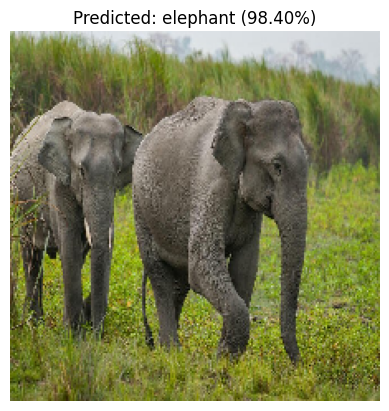

In [34]:
import os

images = os.listdir(elephant_dir)

img_path = os.path.join(elephant_dir, images[0])
print(img_path)
print(os.path.exists(img_path))

predict_animal(img_path)




In [ ]:

test_dir = "/Users/namanpatel/Documents/animal_Images"
print(os.listdir(test_dir))


['lion1.jpg', 'deer1.jpg']


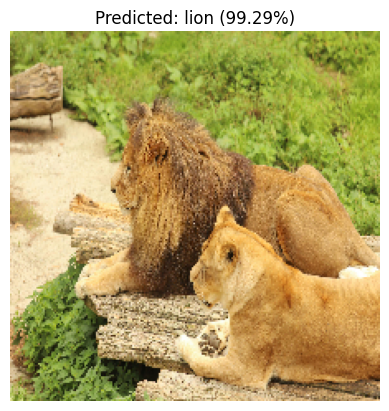

In [42]:
img_path = "/Users/namanpatel/Documents/animal_Images/lion1.jpg"
predict_animal(img_path)


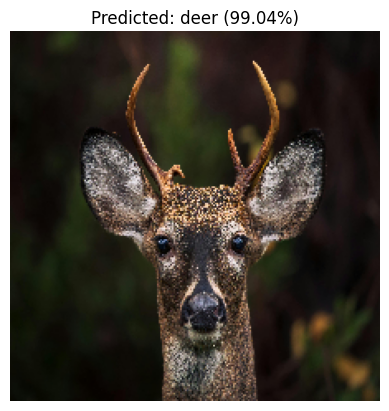

In [43]:

img_name = "deer1.jpg"
img_path = os.path.join(test_dir, img_name)

predict_animal(img_path)


In [39]:
model.save("animal_classifier_mobilenetv2.h5")


/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [40]:
from tensorflow.keras.models import load_model

model_test = load_model("animal_classifier_mobilenetv2.h5")
print("Model loaded successfully!")


Model loaded successfully!


In [44]:
# Get class names from training generator
class_names = list(train_generator.class_indices.keys())

print(len(class_names))
print(class_names[:10])  # sanity check


90
['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat']


In [45]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("✅ class_names.json saved successfully")


✅ class_names.json saved successfully
